# 5 회귀

## 5.1 회귀 소개
- 회귀: 여러 개의 독립변수와 한 개의 종속변수 간의 상관관계를 모델링하는 기법
- 회귀 계수의 선형 여부 -선형 회귀/비선형 회귀, 독립변수의 개수 -단일/다중 회귀
- 지도학습 -분류(이산형 클래스 값)/회귀(연속형 숫자 값)

### 선형 회귀
- 선형 회귀: 실제 값과 예측값의 차이를 최소화하는 직선형 회귀선을 최적화하는 방식
- 대표적인 선형 회귀 모델: 일반 선형 회귀, 릿지, 라쏘, 엘라스틱넷, 로지스틱 회귀

## 5.2 단순 선형 회귀를 통한 회귀 이해
- 단순 선형 회귀: 독립변수, 종속변수 각각 하나인 선형 회귀/ y=ax+b
- 실제 값과 회귀 모델의 차이에 따른 오류 값을 잔차라고 함. 
- 최적의 회귀모델: 전체 데이터의 잔차 합이 최소가 되는 모델(오류 값 합이 최소가 될 수 있는 최적의 회귀 계수를 찾는다는 의미)
- 오류 합을 계산하는 방식: MAE(절댓값을 취해서 더함)/RSS(오류값의 제곱을 구해서 더하는 방식)
- 회귀에서 RSS는 비용(cost), w 변수로 구성되는 RSS를 비용 함수(손실 함수)라고 함.



## 5.3 비용 최소화하기 -경사 하강법(Gradient Descent) 소개
- 점진적으로 반복적인 계산을 통해 W 파라미터 값을 업데이트하면서 오류 값이 최소가 되는 W 파라미터를 구하는 방식

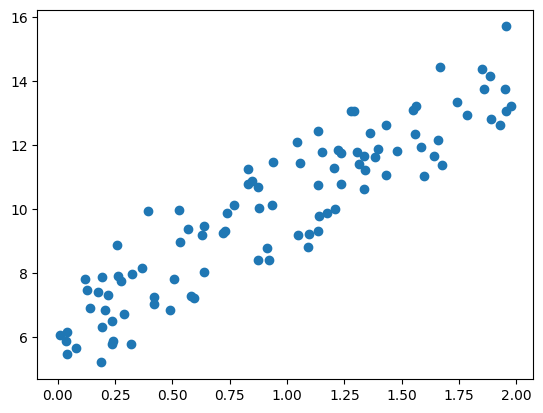

In [82]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

np.random.seed(0)
#y = 4X + 6 식을 근사(w1=4, w0=6). random 값은 Noise를 위해 만듦.
X = 2 * np.random.rand(100,1)
y = 6 +4 * X+ np.random.randn(100,1)

#X, y 데이터 셋 scatter plot으로 시각화
plt.scatter(X, y)

In [83]:
#비용 함수 정의
def get_cost(y, y_pred):
    N = len(y)
    cost = np.sum(np.square(y-y_pred))/N
    return cost

In [84]:
#w1 과 w0 를 업데이트 할 w1_update, w0_update를 반환. 
def get_weight_updates(w1, w0, X, y, learning_rate=0.01):
    N = len(y)
    #먼저 w1_update, w0_update를 각각 w1, w0의 shape와 동일한 크기를 가진 0 값으로 초기화
    w1_update = np.zeros_like(w1)
    w0_update = np.zeros_like(w0)
    #예측 배열 계산하고 예측과 실제 값의 차이 계산
    y_pred = np.dot(X, w1.T) + w0
    diff = y-y_pred
         
    #w0_update를 dot 행렬 연산으로 구하기 위해 모두 1값을 가진 행렬 생성 
    w0_factors = np.ones((N,1))

    #w1과 w0을 업데이트할 w1_update와 w0_update 계산
    w1_update = -(2/N)*learning_rate*(np.dot(X.T, diff))
    w0_update = -(2/N)*learning_rate*(np.dot(w0_factors.T, diff))    
    
    return w1_update, w0_update

In [85]:
#get_weight_updates()을 경사 하강 방식으로 반복적으로 수행하여 w1, w0를 업데이트하는 함수인 gradient_descent_steps() 함수 생성
#입력 인자 iters로 주어진 횟수만큼 반복적으로 w1과 w0를 업데이트 적용함. 
def gradient_descent_steps(X, y, iters=10000):
    #w0와 w1을 모두 0으로 초기화. 
    w0 = np.zeros((1,1))
    w1 = np.zeros((1,1))
    
    #인자로 주어진 iters 만큼 반복적으로 get_weight_updates() 호출하여 w1, w0 업데이트 수행. 
    for ind in range(iters):
        w1_update, w0_update = get_weight_updates(w1, w0, X, y, learning_rate=0.01)
        w1 = w1 - w1_update
        w0 = w0 - w0_update
              
    return w1, w0

In [86]:
def get_cost(y, y_pred):
    N = len(y) 
    cost = np.sum(np.square(y - y_pred))/N
    return cost

w1, w0 = gradient_descent_steps(X, y, iters=1000)
print("w1:{0:.3f} w0:{1:.3f}".format(w1[0,0], w0[0,0]))
y_pred = w1[0,0] * X + w0
print('Gradient Descent Total Cost:{0:.4f}'.format(get_cost(y, y_pred)))
#gradient_descent_steps()를 호출하여 w1, w0 구함.
#get_cost()함수 생성하여 경사 하강법의 예측 오류 계산

w1:4.022 w0:6.162
Gradient Descent Total Cost:0.9935


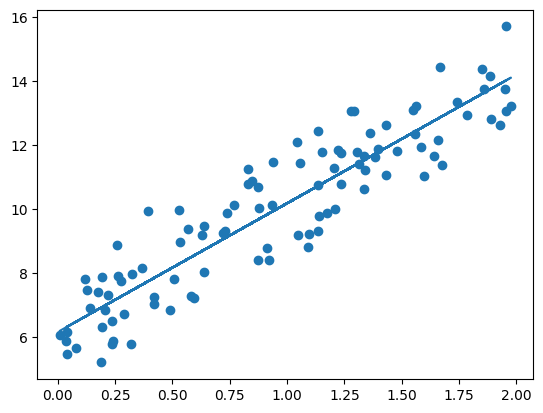

In [87]:
#y_pred에 기반한 회귀선
plt.scatter(X, y)
plt.plot(X,y_pred)

In [88]:
#미니 배치 확률적 경사 하강법을 이용한 최적 비용함수 도출
def stochastic_gradient_descent_steps(X, y, batch_size=10, iters=1000):
    w0 = np.zeros((1,1))
    w1 = np.zeros((1,1))
    prev_cost = 100000
    iter_index =0
    
    for ind in range(iters):
        np.random.seed(ind)
        #전체 X, y 데이터에서 랜덤하게 batch_size만큼 데이터 추출하여 sample_X, sample_y로 저장
        stochastic_random_index = np.random.permutation(X.shape[0])
        sample_X = X[stochastic_random_index[0:batch_size]]
        sample_y = y[stochastic_random_index[0:batch_size]]
        #랜덤하게 batch_size만큼 추출된 데이터 기반으로 w1_update, w0_update 계산 후 업데이트
        w1_update, w0_update = get_weight_updates(w1, w0, sample_X, sample_y, learning_rate=0.01)
        w1 = w1 - w1_update
        w0 = w0 - w0_update
    
    return w1, w0

In [89]:
#stochastic_gradient_descent_steps()를 이용해 w1, w0 및 예측 오류 비용 계산
w1, w0 = stochastic_gradient_descent_steps(X, y, iters=1000)
print("w1:",round(w1[0,0],3),"w0:",round(w0[0,0],3))
y_pred = w1[0,0] * X + w0
print('Stochastic Gradient Descent Total Cost:{0:.4f}'.format(get_cost(y, y_pred)))

w1: 4.028 w0: 6.156
Stochastic Gradient Descent Total Cost:0.9937


## 5.4 사이킷런 LinearRegression을 이용한 보스턴 주택 가격 예측
### LinearRegression 클래스 -Ordinary Least Squares
- LinearRegression 클래스는 예측값과 실제 값의 RSS를 최소화해 OLS 추정 방식으로 구현한 클래스
- LinearRegression 클래스는 fit()메서드로 X, y 배열을 입력받으면 회귀 계수인 W를 coef_ 속성에 저장

In [90]:
#class sklearn.linear_model.LinearRegression(fit_intercept=True, normalize=False, copy_X=True, n_jobs=1)
#입력 파라미터 -fit_intercept: 불린 값, intercept 값의 계산 여부 지정/ normalize: 불린 값, 디폴트 False
#속성 -coef_: fit()메서드 수행 시 회귀 계수가 배열 형태로 저장하는 속성/ intercept: 절편

### 회귀 평가 지표
- MAE: 실제 값과 예측값의 차이를 절댓값으로 변환해 평균
- MSE: 실제 값과 예측값의 차이를 제곱해 평균
- RMSE: MSE에 루트를 씌운 것(MSE값은 오류의 제곱을 구하므로 실제 오류 평균보다 더 커지는 특성o)
- R**2: 분산 기반으로 예측 성능 평가, 실제 값의 분산 대비 예측값의 분산 비율 >1에 가까울수록 예측 정확도 높음

### LinearRegression을 이용해 보스턴 주택 가격 회귀 구현

In [91]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')  #사이킷런 1.2 부터는 보스턴 주택가격 데이터가 없어진다는 warning 메시지 출력 제거
%matplotlib inline

# boston 데이타셋 DataFrame 변환 
bostonDF = pd.read_csv('/Users/na-eunseong/Desktop/cuai_bt/Boston.csv')

print('Boston 데이타셋 크기 :', bostonDF.shape)
bostonDF.head()

Boston 데이타셋 크기 : (506, 15)


,Unnamed: 0,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,2,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,3,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,5,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


- CRIM: 지역별 범죄 발생률
- ZN: 25,000평방피트를 초과하는 거주 지역의 비율
- NDUS: 비상업 지역 넓이 비율
- CHAS: 찰스강에 대한 더미 변수(강의 경계에 위치한 경우는 1, 아니면 0)
- NOX: 일산화질소 농도
- RM: 거주할 수 있는 방 개수
- AGE: 1940년 이전에 건축된 소유 주택의 비율
- DIS: 5개 주요 고용센터까지의 가중 거리
- RAD: 고속도로 접근 용이도
- TAX: 10,000달러당 재산세율
- PTRATIO: 지역의 교사와 학생 수 비율
- B: 지역의 흑인 거주 비율
- LSTAT: 하위 계층의 비율
- MEDV: 본인 소유의 주택 가격(중앙값)

In [92]:
print(bostonDF.columns)

Index(['Unnamed: 0', 'crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis',
       'rad', 'tax', 'ptratio', 'black', 'lstat', 'medv'],
      dtype='str')


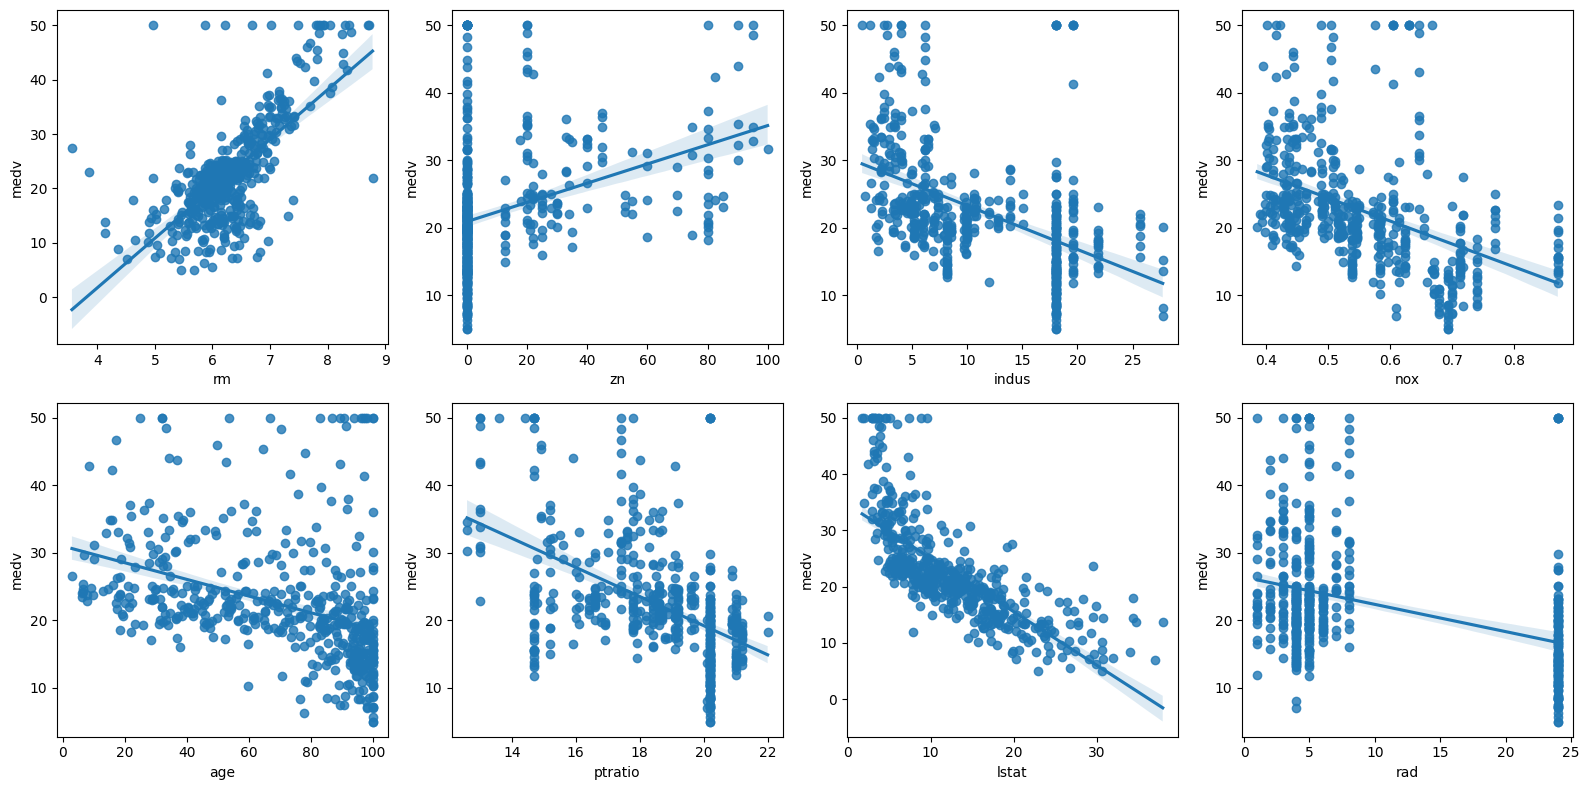

In [93]:
lm_features = ['rm','zn','indus','nox','age','ptratio','lstat','rad']
#2개의 행, 4개의 열을 가진 subplots를 이용. axs는  4*2개의 ax 가짐
fig, axs = plt.subplots(figsize=(16,8), ncols=4, nrows=2)

for i, feature in enumerate(lm_features):
    row = int(i/4)
    col = i%4
    #시본의 regplot 이용해 산점도와 선형 회귀 직선을 함께 표현
    sns.regplot(x=feature, y='medv', data=bostonDF, ax=axs[row][col])

plt.tight_layout()

- 다른 칼럼보다 rm, lstat의 price 영향도가 가장 두드러지게 나타남.
- rm은 양 방향의 선형성이 가장 큼, lstat는 음 방향의 선형성이 가장 큼

In [94]:
#LinearRegression클래스를 이용한 보스턴 주택 가격의 회귀 모델
#train_test_split()을 이용해 학습과 테스트 데이터 세트를 분리해 학습과 예측 수행
#metrics 모듈의 mean_squared_error()와 r2_score()API를 이용해 MSE, R2 score 측정

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

y_target = bostonDF['medv']
X_data = bostonDF.drop(['medv'],axis=1,inplace=False)

X_train , X_test , y_train , y_test = train_test_split(X_data , y_target ,test_size=0.3, random_state=156)

# Linear Regression OLS로 학습/예측/평가 수행. 
lr = LinearRegression()
lr.fit(X_train ,y_train )
y_preds = lr.predict(X_test)
mse = mean_squared_error(y_test, y_preds)
rmse = np.sqrt(mse)

print('MSE : {0:.3f} , RMSE : {1:.3F}'.format(mse , rmse))
print('Variance score : {0:.3f}'.format(r2_score(y_test, y_preds)))

MSE : 17.196 , RMSE : 4.147
Variance score : 0.759


In [95]:
print('절편 값:',lr.intercept_)
print('회귀 계수값:', np.round(lr.coef_, 1))

절편 값: 41.01019999372978
회귀 계수값: [ -0.   -0.1   0.1   0.    3.  -19.6   3.4   0.   -1.8   0.4  -0.   -0.9
   0.   -0.6]


In [96]:
#회귀 계수를 큰 값 순으로 정렬하기 위해 Series로 생성. index가 칼럼명에 유의
coeff = pd.Series(data=np.round(lr.coef_, 1), index=X_data.columns )
coeff.sort_values(ascending=False)

rm             3.4
chas           3.0
rad            0.4
zn             0.1
Unnamed: 0    -0.0
indus          0.0
age            0.0
tax           -0.0
black          0.0
crim          -0.1
lstat         -0.6
ptratio       -0.9
dis           -1.8
nox          -19.6
dtype: float64

In [97]:
from sklearn.model_selection import cross_val_score

y_target = bostonDF['medv']
X_data = bostonDF.drop(['medv'],axis=1,inplace=False)
lr = LinearRegression()

# cross_val_score( )로 5 Fold 셋으로 MSE 를 구한 뒤 이를 기반으로 다시  RMSE 구함. 
neg_mse_scores = cross_val_score(lr, X_data, y_target, scoring="neg_mean_squared_error", cv = 5)
rmse_scores  = np.sqrt(-1 * neg_mse_scores)
avg_rmse = np.mean(rmse_scores)

# cross_val_score(scoring="neg_mean_squared_error")로 반환된 값은 모두 음수 
print(' 5 folds 의 개별 Negative MSE scores: ', np.round(neg_mse_scores, 2))
print(' 5 folds 의 개별 RMSE scores : ', np.round(rmse_scores, 2))
print(' 5 folds 의 평균 RMSE : {0:.3f} '.format(avg_rmse))

 5 folds 의 개별 Negative MSE scores:  [-14.75 -25.07 -32.74 -80.58 -32.16]
 5 folds 의 개별 RMSE scores :  [3.84 5.01 5.72 8.98 5.67]
 5 folds 의 평균 RMSE : 5.844 


## 5.5 다항 회귀와 과(대)적합/과소적합 이해
### 다항 회귀 이해
- 다항 회귀: 다항식으로 표현되는 회귀
- 다항 회귀는 선형 회귀! -회귀 계수에 따라 선형/비선형이 나뉜다는 것 유의

In [98]:
#PolynomialFeatures 클래스를 통해 피처를 다항식 피처로 변환
from sklearn.preprocessing import PolynomialFeatures
import numpy as np

#다항식으로 변환한 단항식 생성, [[0,1],[2,3]]의 2X2 행렬 생성
X = np.arange(4).reshape(2,2)
print('일차 단항식 계수 feature:\n',X )

#degree = 2 인 2차 다항식으로 변환하기 위해 PolynomialFeatures를 이용하여 변환
poly = PolynomialFeatures(degree=2)
poly.fit(X)
poly_ftr = poly.transform(X)
print('변환된 2차 다항식 계수 feature:\n', poly_ftr)

일차 단항식 계수 feature:
 [[0 1]
 [2 3]]
변환된 2차 다항식 계수 feature:
 [[1. 0. 1. 0. 0. 1.]
 [1. 2. 3. 4. 6. 9.]]


In [99]:
#3차 다항식 결정값을 구하는 함수 polynomial_func(X) 생성. 즉 회귀식은 결정값 y = 1+ 2x_1 + 3x_1^2 + 4x_2^3
def polynomial_func(X):
    y = 1 + 2*X[:,0] + 3*X[:,0]**2 + 4*X[:,1]**3
    print(X[:, 0])
    print(X[:, 1])
    return y

X = np.arange(0,4).reshape(2,2)

print('일차 단항식 계수 feature: \n' ,X)
y = polynomial_func(X)
print('삼차 다항식 결정값: \n', y)

일차 단항식 계수 feature: 
 [[0 1]
 [2 3]]
[0 2]
[1 3]
삼차 다항식 결정값: 
 [  5 125]


In [100]:
#3차 다항식 계수의 피처값과 3차 다항식 결정값으로 학습
#3차 다항식 변환 
poly_ftr = PolynomialFeatures(degree=3).fit_transform(X)
print('3차 다항식 계수 feature: \n',poly_ftr)

#Linear Regression에 3차 다항식 계수 feature와 3차 다항식 결정값으로 학습 후 회귀 계수 확인
model = LinearRegression()
model.fit(poly_ftr,y)
print('Polynomial 회귀 계수\n' , np.round(model.coef_, 2))
print('Polynomial 회귀 Shape :', model.coef_.shape)

3차 다항식 계수 feature: 
 [[ 1.  0.  1.  0.  0.  1.  0.  0.  0.  1.]
 [ 1.  2.  3.  4.  6.  9.  8. 12. 18. 27.]]
Polynomial 회귀 계수
 [0.   0.18 0.18 0.36 0.54 0.72 0.72 1.08 1.62 2.34]
Polynomial 회귀 Shape : (10,)


- 사이킷런 파이프라인(Pipeline)을 이용하여 3차 다항회귀 학습
- 사이킷런의 Pipeline 객체는 Feature 엔지니어링 변환과 모델 학습/예측을 순차적으로 결합해줌

In [101]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
import numpy as np

def polynomial_func(X):
    y = 1 + 2*X[:,0] + 3*X[:,0]**2 + 4*X[:,1]**3 
    return y

# Pipeline 객체로 Streamline 하게 Polynomial Feature변환과 Linear Regression을 연결
model = Pipeline([('poly', PolynomialFeatures(degree=3)),
                  ('linear', LinearRegression())])
X = np.arange(4).reshape(2,2)
y = polynomial_func(X)

model = model.fit(X, y)
print('Polynomial 회귀 계수\n', np.round(model.named_steps['linear'].coef_, 2))

Polynomial 회귀 계수
 [0.   0.18 0.18 0.36 0.54 0.72 0.72 1.08 1.62 2.34]


### 다항 회귀를 이용한 과소적합 및 과적합 이해
- cosine 곡선에 약간의 Noise 변동값을 더해 실제값 곡선을 만듦

In [102]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
%matplotlib inline

#임의의 값으로 구성된 X값에 대해 코사인 변환 값을 반환.
def true_fun(X):
    return np.cos(1.5 * np.pi * X)

#X는 0부터 1까지 30개의 임의의 값을 순서대로 샘플링한 데이터입니다.
np.random.seed(0)
n_samples = 30
X = np.sort(np.random.rand(n_samples))

#y값은 코사인 기반의 true_fun()에서 약간의 노이즈 변동 값을 더한 값입니다.
y = true_fun(X) + np.random.randn(n_samples) * 0.1


Degree 1 회귀 계수는 [-1.61] 입니다.
Degree 1 MSE 는 0.4077289625098686 입니다.

Degree 4 회귀 계수는 [  0.47 -17.79  23.59  -7.26] 입니다.
Degree 4 MSE 는 0.043208749872321366 입니다.

Degree 15 회귀 계수는 [-2.98293000e+03  1.03899360e+05 -1.87416098e+06  2.03716227e+07
 -1.44873316e+08  7.09315656e+08 -2.47065940e+09  6.24561535e+09
 -1.15676620e+10  1.56895110e+10 -1.54006219e+10  1.06457414e+10
 -4.91378296e+09  1.35919876e+09 -1.70381099e+08] 입니다.
Degree 15 MSE 는 182621180.60976973 입니다.


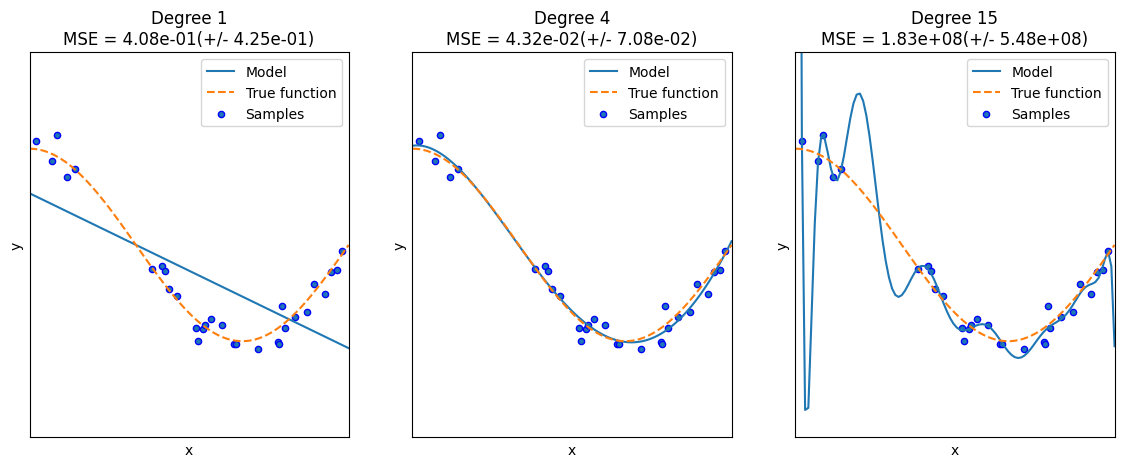

In [103]:
plt.figure(figsize=(14, 5))
degrees = [1, 4, 15]

#다항 회귀의 차수(degree)를 1, 4, 15로 각각 변화시키면서 비교합니다.
for i in range(len(degrees)):
    ax = plt.subplot(1, len(degrees), i + 1)
    plt.setp(ax, xticks=(), yticks=())
    
    #개별 degree별로 Polynomial 변환합니다.
    polynomial_features = PolynomialFeatures(degree=degrees[i], include_bias=False)
    linear_regression = LinearRegression()
    pipeline = Pipeline([("polynomial_features", polynomial_features),
                         ("linear_regression", linear_regression)])
    pipeline.fit(X.reshape(-1, 1), y)
    
    #교차 검증으로 다항 회귀를 평가합니다.
    scores = cross_val_score(pipeline, X.reshape(-1, 1), y, scoring="neg_mean_squared_error", cv=10)
    #Pipeline을 구성하는 세부 객체를 접근하는 named_steps['객체명']을 이용해 회귀계수 추출
    coefficients = pipeline.named_steps['linear_regression'].coef_
    print('\nDegree {0} 회귀 계수는 {1} 입니다.'.format(degrees[i], np.round(coefficients, 2)))
    print('Degree {0} MSE 는 {1} 입니다.'.format(degrees[i], -1*np.mean(scores)))
          
    #0부터 1까지 테스트 데이터 세트를 100개로 나눠 예측을 수행합니다.
    #테스트 데이터 세트에 회귀 예측을 수행하고 예측 곡선과 실제 곡선을 그려서 비교합니다.
    X_test = np.linspace(0, 1, 100)
    #예측값 곡선
    plt.plot(X_test, pipeline.predict(X_test[:, np.newaxis]), label="Model")
    #실제 값 곡선
    plt.plot(X_test, true_fun(X_test), '--', label="True function")
    plt.scatter(X, y, edgecolor='b', s=20, label="Samples")
    plt.xlabel("x"); plt.ylabel("y"); plt.xlim((0, 1)); plt.ylim((-2, 2)); plt.legend(loc="best")
    plt.title("Degree {}\nMSE = {:.2e}(+/- {:.2e})".format(degrees[i], -scores.mean(), scores.std()))
    
plt.show()

- 실선으로 표현된 예측 곡선: 다항 회귀 예측 곡선
- 점선으로 표현된 곡선: 실제 데이터 셋 X, Y의 코사인 곡선
- Degree4 예측 곡선이 실제 데이터 셋과 유사한 모습